## Setup

In [1]:
from gut_former.utils.fig_style import apply_style

apply_style(font_family="DejaVu Serif", base_font_size=16)

In [2]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder
from scipy import stats

warnings.filterwarnings("ignore")

In [3]:
from gut_former.utils.project_paths import find_data_path, find_figures_path

data_path = find_data_path()
output_path = find_data_path().parent / "output"
figures_path = find_figures_path()
figures_path.mkdir(parents=True, exist_ok=True)

## Read Data

In [4]:
latent_df = pd.read_csv(f"{output_path}/latent_sample.csv", index_col=0)

metadata = (
    pd.read_csv(f"{data_path}/metadata_sample.csv", index_col=0, low_memory=False)
    .sort_index()
)
metadata["health_status"] = (metadata["study_condition"] != "control").astype(int)

study_condition_dict = dict(zip(metadata.sample_id, metadata.study_condition))

# Drop samples with multiple diseases, keep latent aligned
metadata = metadata.loc[~metadata["disease"].astype(str).str.contains(";")]
latent_df = latent_df[latent_df.index.isin(metadata.sample_id)]

print(f"latent: {latent_df.shape} | metadata: {metadata.shape}")

latent: (128, 64) | metadata: (128, 142)


In [5]:
def create_y(latent_df, used_dict):
    y_var = latent_df.index.map(used_dict).values.reshape(-1, 1)
    enc = OneHotEncoder(handle_unknown="ignore").fit(y_var)
    y_ohe = enc.transform(y_var).toarray()
    return pd.DataFrame(y_ohe, columns=enc.categories_[0], index=latent_df.index)


Y_df = create_y(latent_df, study_condition_dict)
print("Y_df:", Y_df.shape)

Y_df: (128, 3)


## FACTM rotation

In [6]:
def rotation(mat):
    U, S, Vt = np.linalg.svd(mat)
    return np.dot(Vt.T, U.T)


def dependence_matrix(x, y, metric="pearson"):
    p1, p2 = x.shape[1], y.shape[1]
    results = np.zeros((p1, p2))
    for i in range(p1):
        for j in range(p2):
            mask = ~np.isnan(y[:, j])
            fn = stats.pearsonr if metric == "pearson" else stats.spearmanr
            results[i, j] = fn(x[mask, i], y[mask, j])[0]
    return results


def get_rotated_factors(x, y, metric="pearson"):
    y = np.array(y).astype("float")
    dep_mat = dependence_matrix(x, y, metric)
    return np.dot(rotation(dep_mat), np.array(x).T).T

In [7]:
LATENT_DIM = latent_df.shape[1]
rng = np.random.default_rng(42)

# Pad Y with gaussian noise to latent dim, then rotate latent factors onto it
Y_matrix = np.hstack([Y_df.values, rng.normal(0, 1, size=(Y_df.shape[0], LATENT_DIM - Y_df.shape[1]))])
rotated_x = get_rotated_factors(latent_df.values, Y_matrix, "pearson")
rotated_x_df = pd.DataFrame(rotated_x, columns=[f"latent_{i}" for i in range(LATENT_DIM)],
                            index=latent_df.index)

## Kruskal-Wallis significance

In [8]:
# Kruskal-Wallis: each disease (cases vs matched controls) x each latent factor
res = []
for col in Y_df.columns:
    for fold in range(5):
        x_sick = Y_df[Y_df[col] == 1]
        n_sick = x_sick.shape[0]
        pool = Y_df[Y_df[col] == 0]
        x_ctrl = pool.sample(min(n_sick, len(pool)), random_state=42 + fold)
        for i in range(LATENT_DIM):
            sick = rotated_x_df.loc[rotated_x_df.index.isin(x_sick.index), f"latent_{i}"].values
            ctrl = rotated_x_df.loc[rotated_x_df.index.isin(x_ctrl.index), f"latent_{i}"].values
            if len(sick) < 2 or len(ctrl) < 2:
                continue
            _, pval = stats.kruskal(sick, ctrl)
            res.append({"disease": col, "fold": fold, "latent": i, "pvalue": pval})

df_res = (pd.DataFrame(res)
          .groupby(["latent", "disease"]).mean().drop(columns=["fold"]).reset_index())
df_res["pval_corr"] = stats.false_discovery_control(df_res.pvalue)

pval_mat = df_res.pivot(columns="disease", index="latent", values="pvalue").T
pval_adj = df_res.pivot(columns="disease", index="latent", values="pval_corr").T
pval_mat.index = [i.replace("_", " ") for i in pval_mat.index]

# Figure 3 - FACTM disease x latent significance

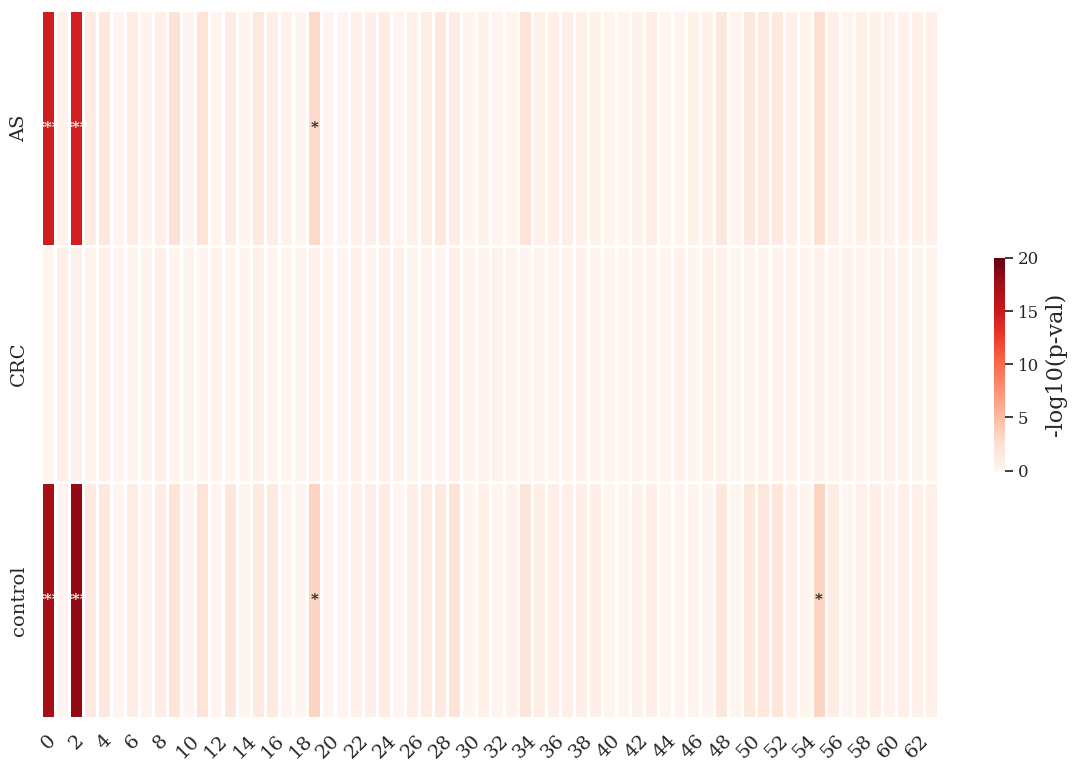

In [9]:
def pval_to_stars(p):
    return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""


annotations = pval_adj.map(pval_to_stars)

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(-np.log10(pval_mat), annot=annotations.values, fmt="", cmap="Reds",
            cbar_kws={"label": "-log10(p-val)", "shrink": 0.3}, ax=ax,
            linecolor="white", vmin=0, lw=1, vmax=20,
            annot_kws={"size": 11, "weight": "bold"})
ax.set_ylabel(""); ax.set_xlabel("")
ax.tick_params(axis="both", labelsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f"{figures_path}/Fig3_factm.png", dpi=300, bbox_inches="tight")
plt.show()